# Synthetic Data Exploration

## What is a Carry Trade?

A **carry trade** exploits the interest rate differential between two currencies:

1. **Borrow** in a low-rate currency (e.g., JPY at 0.25%)
2. **Invest** in a high-rate currency (e.g., USD at 5.25%)
3. **Pocket the difference** (~5% annualized) as daily "swap" credits

**The risk**: If the borrowed currency strengthens, exchange rate losses can overwhelm swap income.

This notebook explores the synthetic data we generated to understand:
- Price behavior of each forex pair
- Volatility patterns
- Interest rate dynamics and swap values
- The relationship between rates and carry profitability

In [1]:
import sys
sys.path.insert(0, '../..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config.settings import DEFAULT_PAIRS
from src.data.generator import SyntheticDataGenerator
from src.data.interest_rates import InterestRateSimulator

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Generate Data

We generate 1 year of hourly data for 3 pairs:
- **USD/JPY**: High carry (USD 5.25% vs JPY 0.25%) - the classic carry trade pair
- **AUD/JPY**: Medium carry (AUD 4.35% vs JPY 0.25%) with uptrend bias
- **EUR/USD**: Negative carry for longs (EUR 4.50% vs USD 5.25%) - costs to hold long

In [2]:
gen = SyntheticDataGenerator(seed=42)

# Static swaps
data_static = gen.generate_all_pairs(days=365, dynamic_rates=False)

# Dynamic swaps (time-varying interest rates)
gen2 = SyntheticDataGenerator(seed=42)
data_dynamic = gen2.generate_all_pairs(days=365, dynamic_rates=True)

for name, df in data_static.items():
    print(f"{name}: {len(df)} bars, price range [{df['close'].min():.2f}, {df['close'].max():.2f}]")

USD/JPY: 6264 bars, price range [145.00, 152.00]
AUD/JPY: 6264 bars, price range [95.00, 102.00]
EUR/USD: 6264 bars, price range [1.06, 1.12]


## 2. Price Charts

### Understanding OHLC
Each bar has 4 prices:
- **Open**: First traded price in the period
- **High**: Highest price reached
- **Low**: Lowest price reached  
- **Close**: Last traded price

The close price is most commonly used for analysis. The high-low range shows **intrabar volatility**.

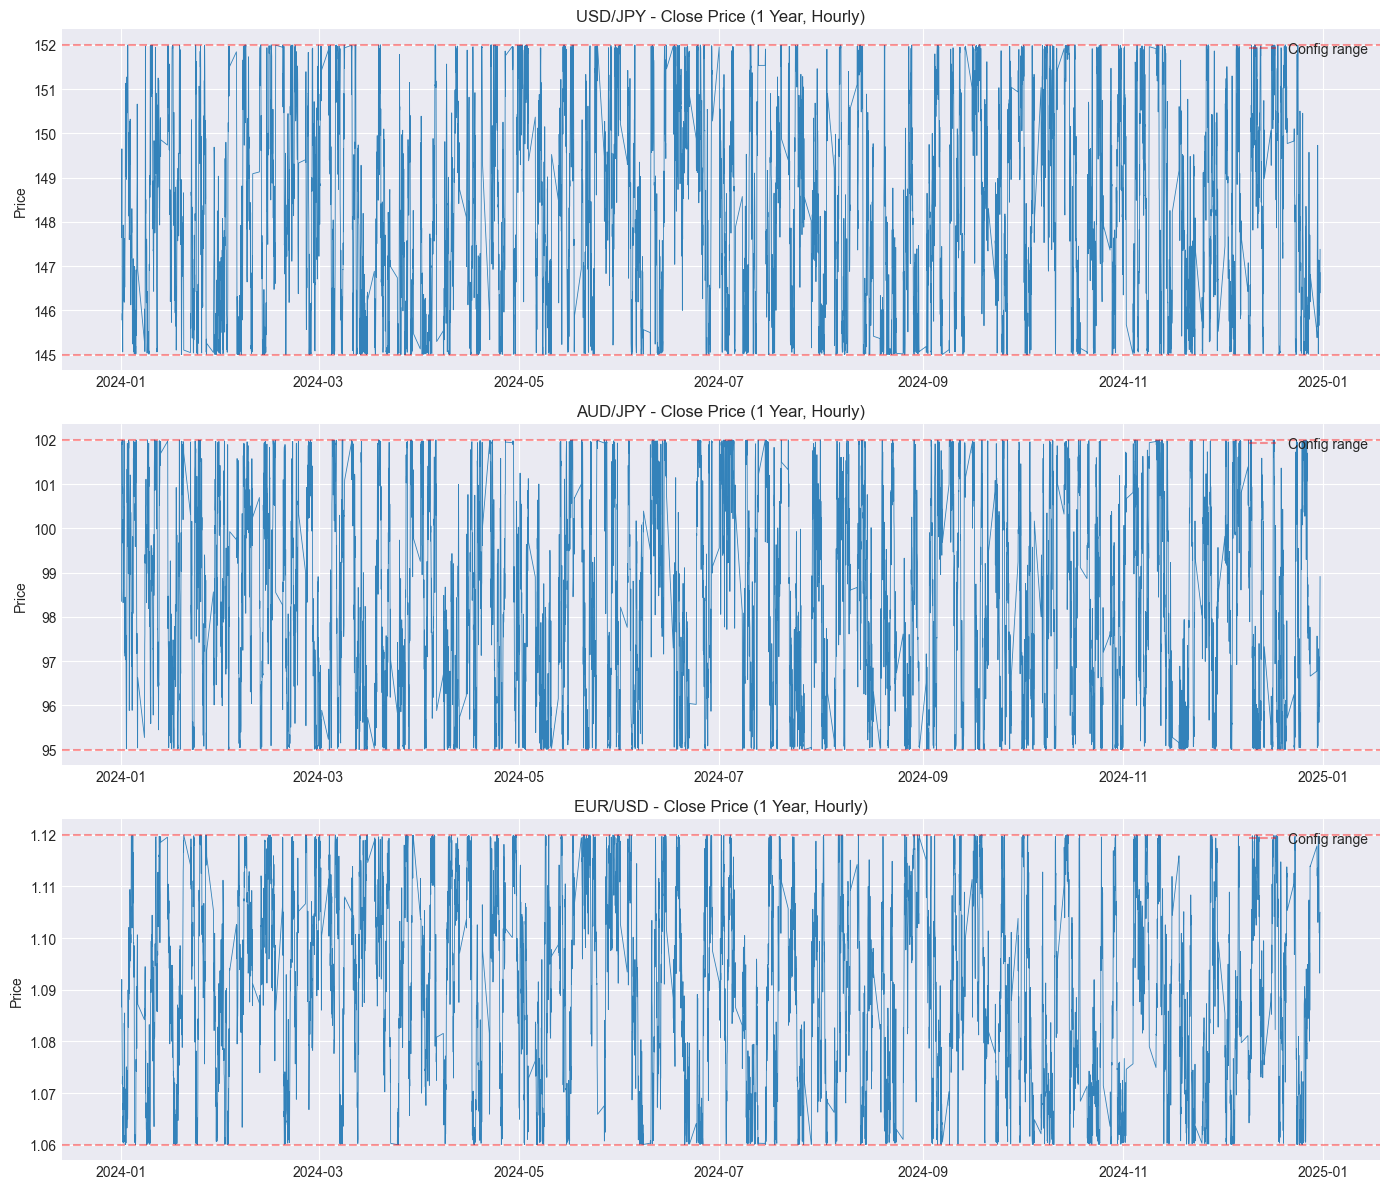

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (name, df) in zip(axes, data_static.items()):
    ax.plot(df['timestamp'], df['close'], linewidth=0.6, alpha=0.9)
    ax.set_title(f'{name} - Close Price (1 Year, Hourly)', fontsize=12)
    ax.set_ylabel('Price')
    # Show configured range
    pair_cfg = [p for p in DEFAULT_PAIRS if p.name == name][0]
    ax.axhline(pair_cfg.price_min, color='red', linestyle='--', alpha=0.4, label='Config range')
    ax.axhline(pair_cfg.price_max, color='red', linestyle='--', alpha=0.4)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. Returns Distribution

### Why Returns Matter More Than Prices
In finance, we analyze **returns** (% change) rather than raw prices because:
- Returns are **scale-free** (comparable across different price levels)
- Returns are (approximately) **stationary** - their statistical properties don't change over time
- Risk metrics (Sharpe, VaR) are computed from returns

A normal distribution of returns would mean symmetric, predictable risk. In reality,
financial returns show **fat tails** (extreme moves happen more often than normal
distributions predict) and sometimes **skew** (more extreme moves in one direction).

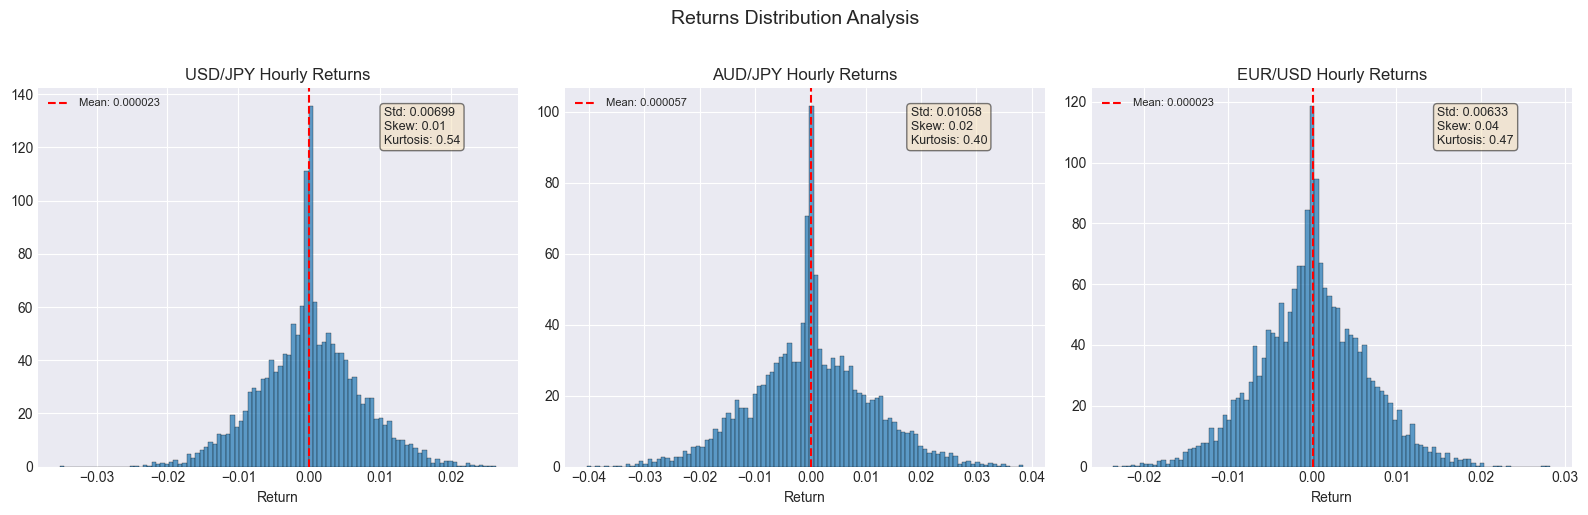

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, df) in zip(axes, data_static.items()):
    returns = df['close'].pct_change().dropna()
    ax.hist(returns, bins=100, alpha=0.7, density=True, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{name} Hourly Returns')
    ax.set_xlabel('Return')
    
    # Stats
    mu = returns.mean()
    sigma = returns.std()
    skew = returns.skew()
    kurt = returns.kurtosis()
    ax.axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.6f}')
    textstr = f'Std: {sigma:.5f}\nSkew: {skew:.2f}\nKurtosis: {kurt:.2f}'
    ax.text(0.72, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=8)

plt.suptitle('Returns Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Volatility Analysis

### What is Volatility?
Volatility measures how much prices fluctuate. It's the **standard deviation of returns**.

For carry trades, volatility is critical:
- **Low volatility** = swap income compounds smoothly = carry trade paradise
- **High volatility** = price swings overwhelm swap income = carry trade nightmare

We compute **rolling volatility** (20-bar window) to see how it changes over time.
Volatility tends to **cluster** - high-vol periods follow high-vol periods.

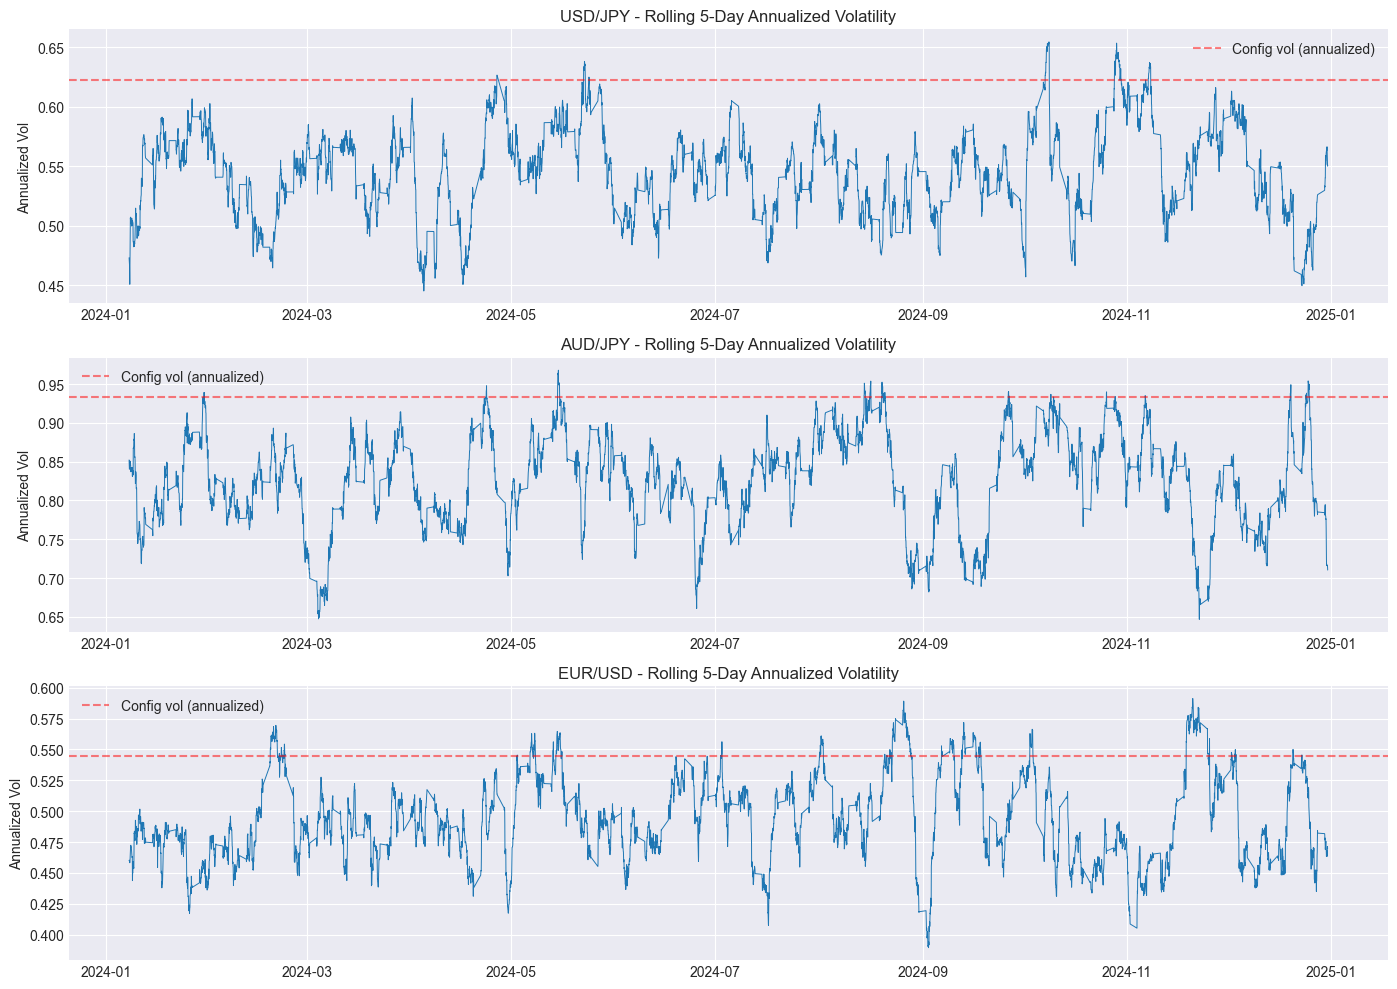

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (name, df) in zip(axes, data_static.items()):
    returns = df['close'].pct_change().dropna()
    rolling_vol = returns.rolling(window=24*5).std() * np.sqrt(24 * 252)  # Annualized
    
    ax.plot(df['timestamp'].iloc[1:], rolling_vol.values, linewidth=0.7)
    ax.set_title(f'{name} - Rolling 5-Day Annualized Volatility')
    ax.set_ylabel('Annualized Vol')
    
    pair_cfg = [p for p in DEFAULT_PAIRS if p.name == name][0]
    ax.axhline(pair_cfg.volatility * np.sqrt(24 * 252), color='red', 
               linestyle='--', alpha=0.5, label=f'Config vol (annualized)')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Interest Rate Dynamics

### How Central Banks Drive Carry Trades

Central banks meet roughly every 6 weeks to decide on interest rates:
- **Rate hike** (+25bps): Currency becomes more attractive → appreciates, carry widens
- **Rate cut** (-25bps): Currency becomes less attractive → depreciates, carry narrows
- **Hold**: No change → status quo

Our simulator uses the **Vasicek model** - rates mean-revert toward a long-term equilibrium,
but only change at discrete "meeting" dates in 25bps steps.

The **rate differential** (base rate - quote rate) determines your daily swap income.

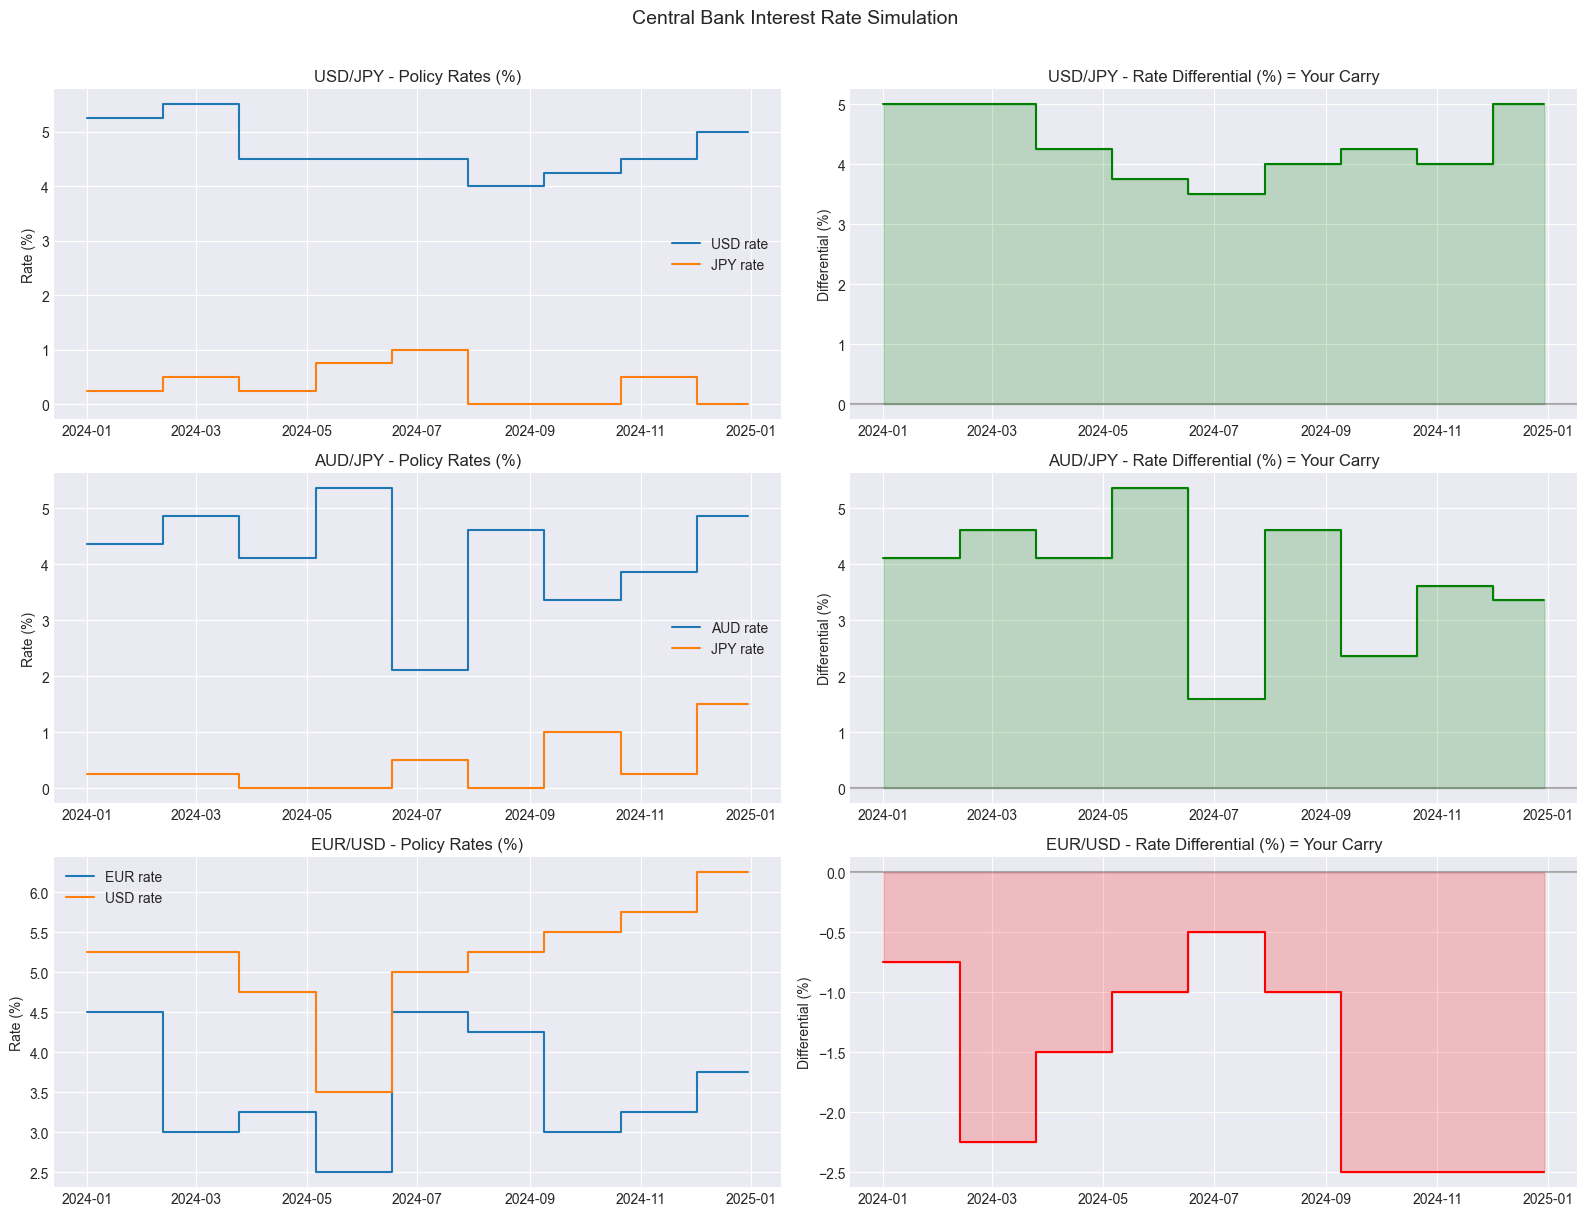

In [6]:
rate_sim = InterestRateSimulator(seed=42)
all_rates = rate_sim.generate_all_pair_rates(DEFAULT_PAIRS, days=365)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, (name, rates_df) in enumerate(all_rates.items()):
    pair_cfg = [p for p in DEFAULT_PAIRS if p.name == name][0]
    base_ccy = name.split('/')[0]
    quote_ccy = name.split('/')[1]
    
    # Left: Individual rates
    ax1 = axes[i, 0]
    ax1.step(rates_df['date'], rates_df['rate_base'] * 100, where='post', 
             label=f'{base_ccy} rate', linewidth=1.5)
    ax1.step(rates_df['date'], rates_df['rate_quote'] * 100, where='post',
             label=f'{quote_ccy} rate', linewidth=1.5)
    ax1.set_title(f'{name} - Policy Rates (%)')
    ax1.set_ylabel('Rate (%)')
    ax1.legend()
    
    # Right: Differential (= the carry)
    ax2 = axes[i, 1]
    ax2.step(rates_df['date'], rates_df['rate_differential'] * 100, where='post',
             color='green' if rates_df['rate_differential'].iloc[0] > 0 else 'red',
             linewidth=1.5)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax2.set_title(f'{name} - Rate Differential (%) = Your Carry')
    ax2.set_ylabel('Differential (%)')
    ax2.fill_between(rates_df['date'], 0, rates_df['rate_differential'] * 100,
                     alpha=0.2, step='post',
                     color='green' if rates_df['rate_differential'].iloc[0] > 0 else 'red')

plt.suptitle('Central Bank Interest Rate Simulation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Swap Income Analysis

### What is Swap?
When you hold a forex position overnight, the broker credits or debits you based on
the interest rate differential. This is the **swap** (also called **rollover**).

- **swap_long > 0**: You EARN money holding a long position (base rate > quote rate)
- **swap_long < 0**: You PAY money holding a long position (base rate < quote rate)
- swap_short is always the opposite sign

Let's compare static vs dynamic swaps to see how rate changes affect income.

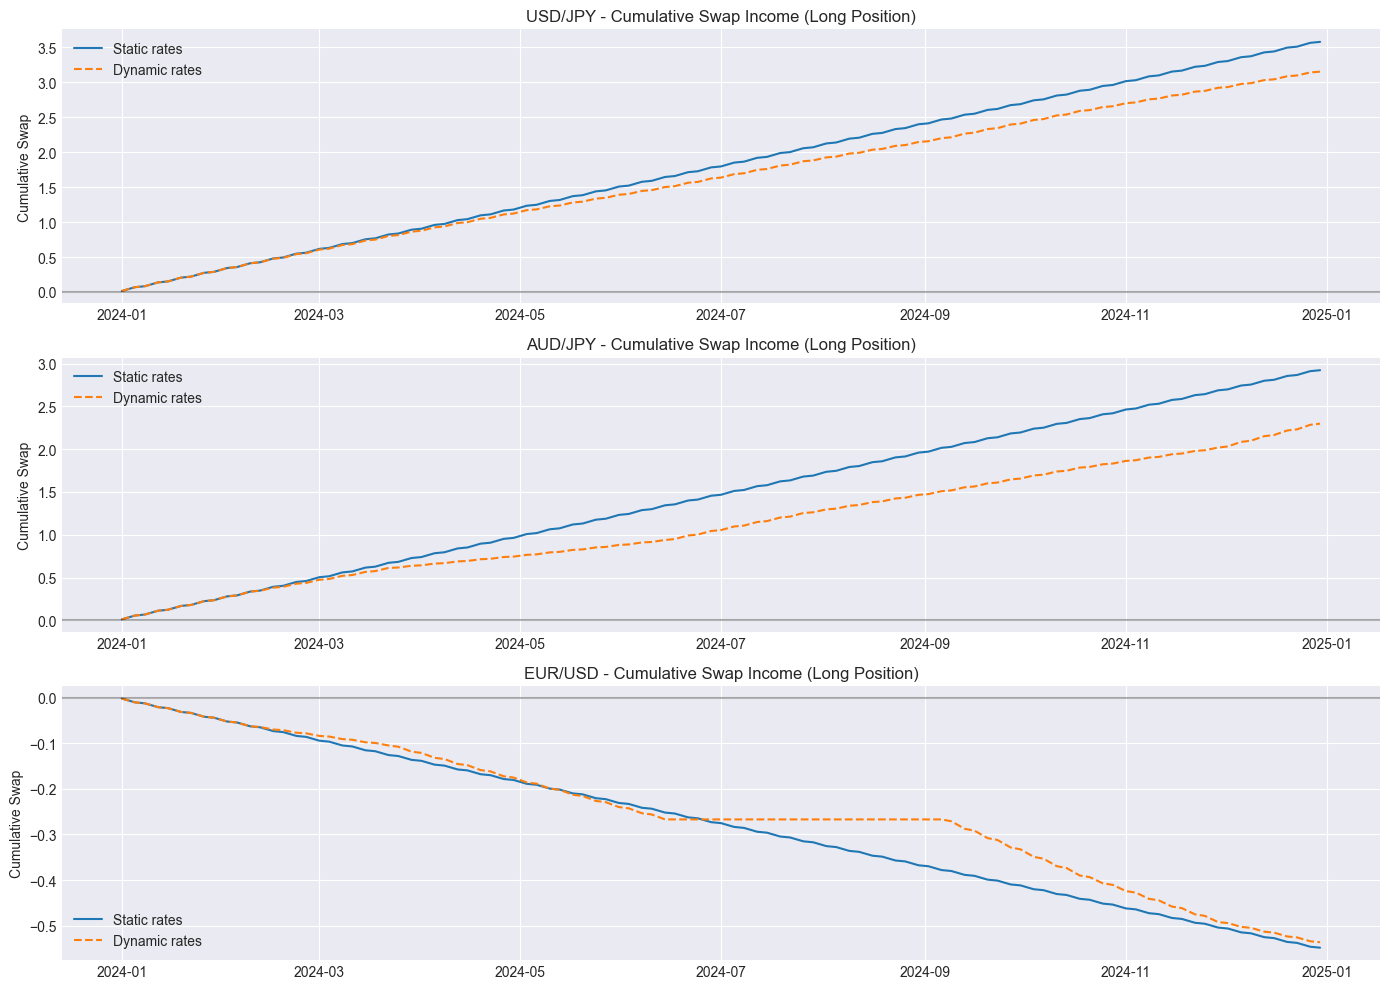

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, name in zip(axes, data_static.keys()):
    df_s = data_static[name]
    df_d = data_dynamic[name]
    
    # Cumulative swap income (assuming 1 lot held long the entire year)
    # Swap is credited once per day, so only count the first bar of each day
    daily_mask_s = ~df_s['timestamp'].dt.date.duplicated()
    daily_mask_d = ~df_d['timestamp'].dt.date.duplicated()
    
    cum_static = df_s.loc[daily_mask_s, 'swap_long'].cumsum()
    cum_dynamic = df_d.loc[daily_mask_d, 'swap_long'].cumsum()
    
    dates_s = df_s.loc[daily_mask_s, 'timestamp']
    dates_d = df_d.loc[daily_mask_d, 'timestamp']
    
    ax.plot(dates_s.values, cum_static.values, label='Static rates', linewidth=1.5)
    ax.plot(dates_d.values, cum_dynamic.values, label='Dynamic rates', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} - Cumulative Swap Income (Long Position)')
    ax.set_ylabel('Cumulative Swap')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [8]:
summary_rows = []
for name, df in data_static.items():
    pair_cfg = [p for p in DEFAULT_PAIRS if p.name == name][0]
    returns = df['close'].pct_change().dropna()
    
    row = {
        'Pair': name,
        'Bars': len(df),
        'Price Min': f"{df['close'].min():.2f}",
        'Price Max': f"{df['close'].max():.2f}",
        'Hourly Vol': f"{returns.std():.6f}",
        'Ann. Vol': f"{returns.std() * np.sqrt(24*252):.2%}",
        'Skewness': f"{returns.skew():.3f}",
        'Kurtosis': f"{returns.kurtosis():.3f}",
        'Rate Diff': f"{(pair_cfg.interest_rate_base - pair_cfg.interest_rate_quote)*100:.2f}%",
        'Swap Long': f"{df['swap_long'].iloc[0]:.4f}",
        'Ann. Carry': f"{df['swap_long'].iloc[0] * 365:.2f}",
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
print("=== Synthetic Data Summary ===")
print(summary.to_string(index=False))
print()
print("Key observations:")
print("- USD/JPY and AUD/JPY have POSITIVE carry (earn swap going long)")
print("- EUR/USD has NEGATIVE carry (pay swap going long, earn going short)")
print("- Higher volatility pairs need larger rate differentials to justify the risk")

=== Synthetic Data Summary ===
   Pair  Bars Price Min Price Max Hourly Vol Ann. Vol Skewness Kurtosis Rate Diff Swap Long Ann. Carry
USD/JPY  6264    145.00    152.00   0.006993   54.38%    0.006    0.536     5.00%    0.0137       5.00
AUD/JPY  6264     95.00    102.00   0.010577   82.26%    0.024    0.402     4.10%    0.0112       4.09
EUR/USD  6264      1.06      1.12   0.006334   49.26%    0.039    0.470    -0.75%   -0.0021      -0.77

Key observations:
- USD/JPY and AUD/JPY have POSITIVE carry (earn swap going long)
- EUR/USD has NEGATIVE carry (pay swap going long, earn going short)
- Higher volatility pairs need larger rate differentials to justify the risk


## Key Takeaways

1. **Carry = rate differential**: The bigger the gap between base and quote rates, the more you earn daily
2. **Volatility is the enemy**: Price swings can erase weeks of swap income in hours
3. **Rates aren't static**: Central bank decisions change the carry over time — a widening differential is bullish for carry, narrowing is bearish
4. **Not all pairs are equal**: USD/JPY offers the biggest carry but sideways price action; AUD/JPY has uptrend bias but more volatility; EUR/USD actually costs you to hold long

**Next step (Phase 2):** Build a strategy that decides WHEN to enter/exit carry trades based on these characteristics.